# Site Setup

Define your site once, interactively, and save a reusable JSON configuration that every other historical rainfall notebook will load.

**Prerequisites:** run this notebook before `a_Total_rainfall`, `b_Consecutive_dry_days` or `c_Heavy_rainfall`.

**Outputs:**
- `data/sites/<site>.json` — site configuration (station ID, coordinates, reference period).
- `data/rainfall/GHCN_<station_id>.pkl` — cleaned daily `PRCP` time series (mm).

**Workflow overview:**

1. Load the GHCN country catalog and inspect the map.
2. Enter your **country** and resolve the official GHCN country code.
3. List stations for that country and pick one **station ID**.
4. Auto-fill **site name**, **longitude** and **latitude** from the selected station.
5. Set **variables of interest** (`PRCP`), **reference period** and **completeness threshold**.
6. Save the site configuration JSON.
7. Download, filter and cache daily precipitation.
8. Apply the time-completeness quality filter.
9. Inspect the downloaded series.


In [1]:
from pathlib import Path
import sys

import pandas as pd
import plotly.express as px
from IPython.display import display

sys.path.append("../../functions")
from rainfall import save_site_config, site_config_filename
from data_downloaders import GHCN, filter_by_time_completeness


/Users/laurac/Library/Mobile Documents/com~apple~CloudDocs/Projects/CC_indicators/PICCM/PICCM_Rainfall/notebooks/historical/../../functions/data_downloaders.py:300: SyntaxWarning: invalid escape sequence '\s'
  StringIO(content), skiprows=1, sep='\s+', header=None, index_col=0


## 1. Site fields (auto-filled after station choice)

`site_name`, `site_lon` and `site_lat` are initialised as `None` and populated automatically in Step 5 when a GHCN station is selected.


In [2]:
site_name = None
site_lon = None
site_lat = None

print("Site fields will be set automatically after selecting a station (Step 5).")


Site fields will be set automatically after selecting a station (Step 5).


## 2. Load the GHCN country catalog

This step downloads the official GHCN country code table (`Code`, `Country`) used by the map and by the country lookup step.


In [3]:
df_countries = GHCN.download_country_codes()
print(f"Loaded {len(df_countries)} country entries from GHCN.")
df_countries


Loaded 220 country entries from GHCN.


,Code,Country
0,AC,Antigua and Barbuda
1,AE,United Arab Emirates
2,AF,Afghanistan
3,AG,Algeria
4,AJ,Azerbaijan
...,...,...
215,WQ,Wake Island [United States]
216,WZ,Swaziland
217,ZA,Zambia
218,ZI,Zimbabwe


### Map of available countries

Each purple marker is one GHCN country, placed at the **median** latitude/longitude of all its stations. Hover for the country `Code`, full `Country` name and number of stations.

Use this map to identify the exact GHCN `Country` name, then set `country` in Step 3.


In [4]:
try:
    df_stations
except NameError:
    df_stations = GHCN.download_stations_info()

try:
    df_countries
except NameError:
    df_countries = GHCN.download_country_codes()

df_stations["Code"] = df_stations["ID"].str[:2]
country_centroids = (
    df_stations.groupby("Code")
    .agg(
        Latitude=("Latitude", "median"),
        Longitude=("Longitude", "median"),
        n_stations=("ID", "count"),
    )
    .reset_index()
)
country_map = country_centroids.merge(df_countries, on="Code", how="left")

center_lat = float(country_map["Latitude"].median())
center_lon = float(country_map["Longitude"].median())

fig = px.scatter_mapbox(
    country_map,
    lat="Latitude", lon="Longitude",
    hover_name="Country",
    hover_data={
        "Code": True,
        "n_stations": True,
        "Latitude": ":.2f",
        "Longitude": ":.2f",
    },
    color_discrete_sequence=["#8e44ad"],
    center={"lat": center_lat, "lon": center_lon},
    zoom=1.6,
    height=560,
)
fig.update_layout(
    mapbox_style="open-street-map",
    margin=dict(l=0, r=0, t=90, b=0),
    title=dict(
        text=f"GHCN countries (median station location) - {len(country_centroids)} countries",
        x=0.5, xanchor="center",
        y=0.985, yanchor="top",
        pad=dict(t=10),
        font=dict(size=13),
    ),
    modebar=dict(orientation="v", bgcolor="rgba(255,255,255,0.6)"),
)
fig.show(config={"scrollZoom": False})


## 3. Choose country and resolve GHCN code

Set `country` to the exact GHCN country name (use the map above to identify the correct spelling). The notebook resolves the two-letter GHCN country code used to filter stations in the next step.

If no exact match is found, a list of similar country names is displayed — copy the correct name back into `country` and re-run.


In [5]:
country = "Palau"  # e.g. "Palau"

assert country.strip(), "Set `country` with a GHCN country name before running this cell."

exact = GHCN.get_country_code(country)

if len(exact) == 1:
    country_code = exact["Code"].iloc[0]
    country_name = exact["Country"].iloc[0]
    print(f"Exact match: {country_name!r} -> code {country_code!r}")
else:
    suggestions = df_countries[
        df_countries["Country"].str.contains(country, case=False, na=False)
    ]
    if len(suggestions) == 0:
        print(
            f"No country matches {country!r}. Showing the full list so you can "
            "pick one; copy it back into the `country` variable above and re-run."
        )
        display(df_countries)
    else:
        print(
            f"{len(suggestions)} possible matches for {country!r}. "
            "Copy the exact name into `country` above and re-run this step."
        )
        display(suggestions)
    country_code = None
    country_name = None


Exact match: 'Palau' -> code 'PS'


## 4. List stations for the selected country

Downloads the full GHCN-Daily station list and element inventory, filters to the selected country code, and merges each station's period of record for `PRCP`.

The interactive map and table below help you choose a station with a long, reliable precipitation record.


In [6]:
assert country_code is not None, "Resolve the country code in Step 3 before running this cell."

df_stations = GHCN.download_stations_info()
df_inventory = GHCN.download_station_inventory()
df_country_stations = df_stations[df_stations["ID"].str.startswith(country_code)].copy()

nearest = (
    df_country_stations
    .sort_values(["Name", "ID"])
    .reset_index(drop=True)
)

record_years = GHCN.summarize_record_years(df_inventory, nearest["ID"])
nearest = nearest.merge(record_years, on="ID", how="left")

print(f"{len(nearest)} GHCN stations registered under country code {country_code!r}.")


13 GHCN stations registered under country code 'PS'.


### Map of country stations

Each blue marker is one GHCN station. Hover for the station ID, name, elevation and record span. Pick a station ID for Step 5.


In [7]:
map_df = nearest.copy()
center_lat = float(map_df["Latitude"].median())
center_lon = float(map_df["Longitude"].median())

lat_span = float(map_df["Latitude"].max() - map_df["Latitude"].min())
lon_span = float(map_df["Longitude"].max() - map_df["Longitude"].min())
span = max(lat_span, lon_span)
if span < 0.5:
    zoom = 10
elif span < 1.5:
    zoom = 8
elif span < 5:
    zoom = 6
else:
    zoom = 4

fig = px.scatter_mapbox(
    map_df,
    lat="Latitude", lon="Longitude",
    color_discrete_sequence=["#3498db"],
    hover_name="Name",
    hover_data={
        "ID": True,
        "Elevation": True,
        "record_years": True,
        "elements": True,
        "Latitude": ":.3f",
        "Longitude": ":.3f",
    },
    center={"lat": center_lat, "lon": center_lon},
    zoom=zoom,
    height=500,
)
fig.update_layout(
    mapbox_style="open-street-map",
    height=560,
    margin=dict(l=0, r=0, t=90, b=0),
    title=dict(
        text=f"GHCN stations in {country_name} ({len(map_df)} stations)",
        x=0.5, xanchor="center",
        y=0.985, yanchor="top",
        pad=dict(t=10),
        font=dict(size=13),
    ),
    showlegend=False,
    modebar=dict(orientation="v", bgcolor="rgba(255,255,255,0.6)"),
)
fig.show(config={"scrollZoom": False})


In [8]:
station_table_cols = [
    "ID", "Name", "Latitude", "Longitude", "Elevation",
    "record_start", "record_end", "record_years", "elements",
]
display(nearest[station_table_cols].head(30))


,ID,Name,Latitude,Longitude,Elevation,record_start,record_end,record_years,elements
0,PSC00914015,PW AIMELIK BABELTHUAP,7.4500,134.5167,60.0,1953,1955,1953-1955,PRCP
1,PSC00914030,PW ANGUAR,6.9167,134.1500,6.1,1955,1977,1955-1977,PRCP
2,PSW00040309,PW KOROR GSN 91408,7.3367,134.4769,27.4,1951,2026,1951-2026,PRCP
3,PSW00040307,PW KOROR ISLAND NF,7.3333,134.4833,30.2,1947,1951,1947-1951,PRCP
4,PSC00914465,PW MALAKAL RSCH,7.3333,134.4500,75.9,1955,1955,1955-1955,PRCP
5,PSC00914478,PW MARICULTURE CTR,7.3333,134.4500,3.0,1990,2004,1990-2004,PRCP
6,PSC00914519,PW NEKKEN FORESTRY,7.4500,134.5000,31.1,1983,2026,1983-2026,PRCP
7,PSC00914580,PW NGASANG BABELTHUAP,7.6333,134.6500,3.0,1955,1979,1955-1979,PRCP
8,PSC00914712,PW PELELIU,7.0333,134.2667,3.0,1991,2026,1991-2026,PRCP
9,PSW00040305,PW PELELIU ISLAND PALAU ISLANDS,7.0000,134.2500,5.2,1945,1947,1945-1947,PRCP


## 5. Pick a station and auto-fill site metadata

Set `ghcn_station_id` to one of the IDs from the table in Step 4. The notebook auto-fills `site_lon`, `site_lat` and `ghcn_station_name` from the GHCN metadata.

`site_name` is a display label used in outputs (defaults to the country name but can be overridden).


In [9]:
ghcn_station_id = "PSW00040309"  # choose an ID from the table in Step 4
site_name = "Palau"

assert ghcn_station_id in nearest["ID"].values, (
    f"Station ID {ghcn_station_id!r} not found among stations for country code {country_code!r}."
)
station_row = nearest.loc[nearest["ID"] == ghcn_station_id].iloc[[0]]

ghcn_station_name = station_row["Name"].iloc[0]
site_lon = float(station_row["Longitude"].iloc[0])
site_lat = float(station_row["Latitude"].iloc[0])

print(f"Selected station: {ghcn_station_id} - {ghcn_station_name}")
print(f"Auto-filled site coordinates: ({site_lat:+.3f}, {site_lon:+.3f})")
print(f"Auto-filled site name: {site_name}")


Selected station: PSW00040309 - PW KOROR GSN 91408
Auto-filled site coordinates: (+7.337, +134.477)
Auto-filled site name: Palau


## 6. Variables and reference period

| Parameter | Default | Description |
|---|---|---|
| `vars_interest` | `["PRCP"]` | GHCN variable to download (daily precipitation) |
| `reference_period_start` / `_end` | `"1961"` / `"1990"` | WMO climatology baseline for anomalies |
| `completeness_threshold` | `0.75` | Minimum data completeness to keep a month/year |


In [10]:
vars_interest = ["PRCP"]
reference_period_start = "1961"
reference_period_end = "1990"
completeness_threshold = 0.75

print(f"Variables of interest: {vars_interest}")
print(f"Reference period: {reference_period_start}-{reference_period_end}")
print(f"Completeness threshold: {completeness_threshold:.0%}")


Variables of interest: ['PRCP']
Reference period: 1961-1990
Completeness threshold: 75%


## 7. Save the site configuration

Writes `data/sites/<site>.json` with all site metadata. Analysis notebooks load this file via `load_site_config()` — never hardcode site values in `a`, `b` or `c`.


In [11]:
site_config = {
    "site_name": site_name,
    "site_lon": float(site_lon),
    "site_lat": float(site_lat),
    "country": country_name,
    "ghcn_station_id": ghcn_station_id,
    "ghcn_station_name": ghcn_station_name,
    "vars_interest": list(vars_interest),
    "reference_period_start": str(reference_period_start),
    "reference_period_end": str(reference_period_end),
    "completeness_threshold": float(completeness_threshold),
}

config_out = Path("../../data/sites") / site_config_filename(site_name)

save_site_config(site_config, config_out)
print(f"Saved site config: {config_out.resolve()}")
site_config


Saved site config: /Users/laurac/Library/Mobile Documents/com~apple~CloudDocs/Projects/CC_indicators/PICCM/PICCM_Rainfall/data/sites/palau.json


{'site_name': 'Palau',
 'site_lon': 134.4769,
 'site_lat': 7.3367,
 'country': 'Palau',
 'ghcn_station_id': 'PSW00040309',
 'ghcn_station_name': 'PW KOROR GSN 91408',
 'vars_interest': ['PRCP'],
 'reference_period_start': '1961',
 'reference_period_end': '1990',
 'completeness_threshold': 0.75}

## 8. Download and cache GHCN station data

Downloads daily `PRCP` from GHCN-Daily and caches the result at `data/rainfall/GHCN_<station_id>.pkl`.

Set `force_redownload = True` to refresh the cache from NOAA servers.


In [12]:
force_redownload = False

GHCND_dir = "https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/access/"
data_dir = Path("../../data/rainfall")
data_dir.mkdir(parents=True, exist_ok=True)
pickle_path = data_dir / f"GHCN_{ghcn_station_id}.pkl"

if pickle_path.exists() and not force_redownload:
    data = pd.read_pickle(pickle_path)
    print(f"Loaded cached data: {pickle_path}")
    print("Set force_redownload = True above to refresh.")
else:
    print(f"Downloading {', '.join(vars_interest)} for station {ghcn_station_id}...")
    df_target = df_country_stations.loc[df_country_stations["ID"] == ghcn_station_id]

    frames = []
    for var in vars_interest:
        result, _ = GHCN.extract_dict_data_var(GHCND_dir, var, df_target)
        if not result:
            print(f"  WARNING: variable {var!r} not available for {ghcn_station_id}.")
            continue
        frames.append(result[0]["data"])

    if not frames:
        raise RuntimeError(
            f"None of {vars_interest} are available for station {ghcn_station_id}."
        )

    data = pd.concat(frames, axis=1).dropna()
    data.to_pickle(pickle_path)
    print(f"Saved {len(data)} rows to {pickle_path}")

print(f"Date range: {data.index.min().date()} to {data.index.max().date()}")
data.head()


Saved 26847 rows to ../../data/rainfall/GHCN_PSW00040309.pkl
Date range: 1951-07-01 to 2026-06-16


/Users/laurac/Library/Mobile Documents/com~apple~CloudDocs/Projects/CC_indicators/PICCM/PICCM_Rainfall/notebooks/historical/../../functions/data_downloaders.py:235: DtypeWarning:

Columns (17,19,21,23,25,27,29,31,33,35,37,39,41,43,45,47,49,51,53,55,57,59,61,63,65,67,69,71,73,75,77,79,81,83,85,87,89,91) have mixed types. Specify dtype option on import or set low_memory=False.



,PRCP
DATE,
1951-07-01,0.0
1951-07-02,0.8
1951-07-03,3.8
1951-07-04,18.3
1951-07-05,0.0


## 9. Time-completeness filter

Applies `filter_by_time_completeness()` to remove months and years with insufficient observations (default: fewer than 75% of expected days/months). The filtered DataFrame overwrites the cached pickle.


In [13]:
df_filt, removed_months, removed_years = filter_by_time_completeness(
    data,
    month_threshold=completeness_threshold,
    year_threshold=completeness_threshold,
)
print(f"Removed {removed_months.shape[0]} months due to insufficient data: {removed_months.index.tolist()}")
print(f"Removed {removed_years.shape[0]} years due to insufficient data: {removed_years.index.tolist()}")

data = df_filt
data.to_pickle(pickle_path)
print(f"Updated cached pickle: {pickle_path}")


Removed 9 months due to insufficient data: [(2018, 8), (2019, 1), (2022, 7), (2022, 11), (2022, 12), (2023, 1), (2023, 8), (2024, 2), (2026, 6)]
Removed 1 years due to insufficient data: [2019]
Updated cached pickle: ../../data/rainfall/GHCN_PSW00040309.pkl


## 10. Quick look at the downloaded data

Sanity-check plot showing daily `PRCP`, monthly sums and annual totals. This is a quality-control figure, not a published indicator.

**Next step:** open `a_Total_rainfall.ipynb` to analyse total and accumulated rainfall.


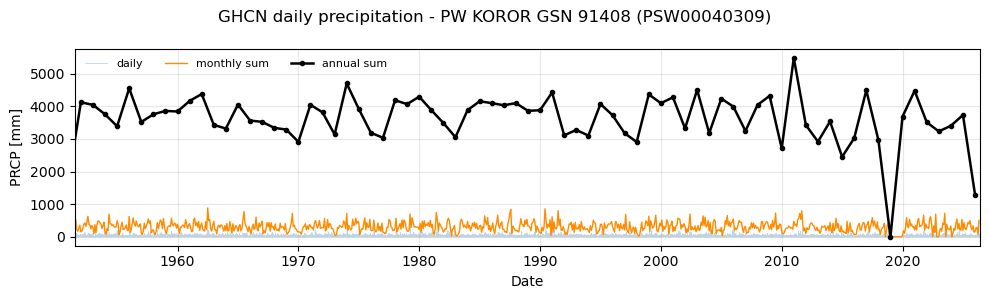

In [14]:
import matplotlib.pyplot as plt

monthly = data["PRCP"].resample("MS").sum()
annual = data["PRCP"].resample("YS").sum()

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(data.index, data["PRCP"], lw=0.6, color="steelblue", alpha=0.35, label="daily")
ax.plot(monthly.index, monthly, lw=1.0, color="darkorange", label="monthly sum")
ax.plot(annual.index, annual, lw=1.8, color="black", marker="o", ms=3, label="annual sum")
ax.set_xlim(data.index.min(), data.index.max())
ax.set_ylabel("PRCP [mm]")
ax.legend(loc="upper left", ncol=3, fontsize=8, frameon=False)
ax.set_xlabel("Date")
ax.grid(alpha=0.3)
fig.suptitle(f"GHCN daily precipitation - {ghcn_station_name} ({ghcn_station_id})")
fig.tight_layout()
plt.show()
